### Task 1: Splitting Strategies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold

In [2]:
# Load the Digits dataset
digits = load_digits()

# X contains the 64 pixel features, y contains the digit labels
X = digits.data
y = digits.target

# Convert the feature matrix into a DataFrame
digits_df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])

# Add the target column
digits_df["target"] = y

# Display the first rows
digits_df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [3]:
# Count how many samples exist for each digit class
class_distribution = digits_df["target"].value_counts().sort_index()

print("Class distribution:")
print(class_distribution)

print("\nClass distribution as percentage:")
print((class_distribution / len(digits_df) * 100).round(2))

Class distribution:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Class distribution as percentage:
target
0     9.91
1    10.13
2     9.85
3    10.18
4    10.07
5    10.13
6    10.07
7     9.96
8     9.68
9    10.02
Name: count, dtype: float64


In [4]:
# Split the data into 80% training and 20% testing
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test)

# Calculate test accuracy
single_split_accuracy = accuracy_score(y_test, y_pred)

print(f"Single 80/20 split test accuracy: {single_split_accuracy:.4f}")

Single 80/20 split test accuracy: 0.9750


In [5]:
# Regular K-Fold cross-validation
# shuffle=True is used so the data is randomly mixed before creating folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print("Regular 5-Fold CV scores:")
print(kfold_scores)
print(f"Mean accuracy: {kfold_scores.mean():.4f}")
print(f"Standard deviation: {kfold_scores.std():.4f}")

Regular 5-Fold CV scores:
[0.95833333 0.96875    0.96167247 0.96167247 0.95121951]
Mean accuracy: 0.9603
Standard deviation: 0.0057


In [6]:
# Stratified K-Fold keeps the class distribution similar in each fold
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring="accuracy"
)

print("Stratified 5-Fold CV scores:")
print(stratified_scores)
print(f"Mean accuracy: {stratified_scores.mean():.4f}")
print(f"Standard deviation: {stratified_scores.std():.4f}")

Stratified 5-Fold CV scores:
[0.97222222 0.94444444 0.97212544 0.95121951 0.96515679]
Mean accuracy: 0.9610
Standard deviation: 0.0113


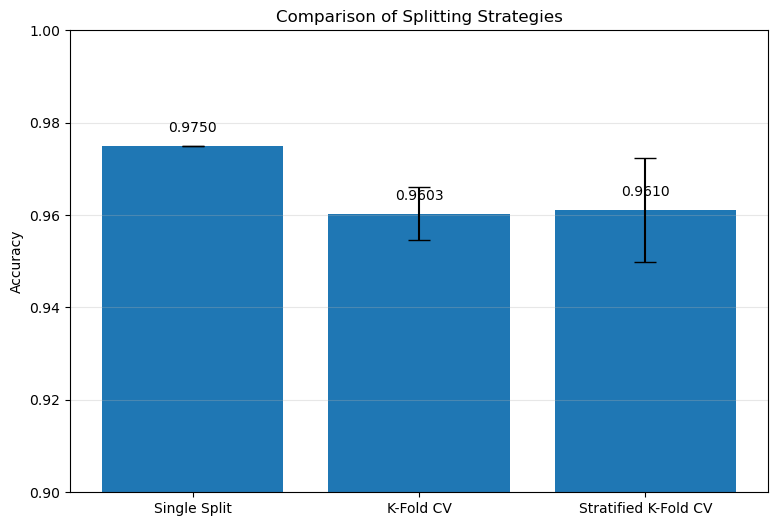

In [7]:
# Prepare results for plotting
methods = ["Single Split", "K-Fold CV", "Stratified K-Fold CV"]
mean_scores = [
    single_split_accuracy,
    kfold_scores.mean(),
    stratified_scores.mean()
]

# Error bars: single split has no CV standard deviation, so its error is 0
error_bars = [
    0,
    kfold_scores.std(),
    stratified_scores.std()
]

plt.figure(figsize=(9, 6))
plt.bar(methods, mean_scores, yerr=error_bars, capsize=8)

plt.ylim(0.90, 1.00)
plt.ylabel("Accuracy")
plt.title("Comparison of Splitting Strategies")
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(mean_scores):
    plt.text(i, score + 0.003, f"{score:.4f}", ha="center")

plt.show()

## Task 1 Interpretation

In this task, the Digits dataset was loaded and converted into a DataFrame. The dataset contains handwritten digit images, where each image is represented by 64 pixel features and one target label. The target values represent the digit classes from 0 to 9.

The class distribution shows that the dataset is roughly balanced. Each digit class has a very similar number of samples, usually around 9.7% to 10.2% of the full dataset. This means that no digit class strongly dominates the dataset.

Using a single 80/20 train/test split, the Logistic Regression model achieved an accuracy of 0.9750. This is the highest value among the three reported results. However, this result is based on only one random split, so it may be slightly optimistic depending on which samples were placed in the test set.

Regular 5-fold cross-validation produced a mean accuracy of 0.9603 with a standard deviation of 0.0057. This gives a more reliable estimate than a single split because the model is trained and evaluated five times on different folds.

Stratified 5-fold cross-validation produced a mean accuracy of 0.9610 with a standard deviation of 0.0113. Its mean accuracy is very close to regular K-Fold because the Digits dataset is already well balanced. The main advantage of stratification is that it keeps the class proportions similar in each fold.

The bar chart shows that all three strategies give high accuracy values. The single split result is slightly higher, while the two cross-validation methods are close to each other. This supports the idea that cross-validation gives a more stable and realistic estimate of model performance.

Stratified splitting matters even when the dataset is roughly balanced because random folds can still accidentally contain slightly different class proportions. This becomes more important when the dataset is smaller or when some classes are harder to classify. A larger difference between regular K-Fold and Stratified K-Fold would be expected in an imbalanced dataset, for example when one class represents most of the data and another class has very few samples.

### Task 2: Model Comparison with Cross-Validation

In [8]:
# Define the five classifiers required for Task 2
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# Use Stratified 5-Fold CV to preserve class distribution in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
# Store all model comparison results here
results = []

# Evaluate each model with stratified 5-fold cross-validation
for model_name, model in models.items():
    accuracy_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="accuracy"
    )
    
    precision_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="precision_macro"
    )
    
    recall_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="recall_macro"
    )
    
    f1_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="f1_macro"
    )
    
    results.append({
        "Model": model_name,
        "Accuracy Mean": accuracy_scores.mean(),
        "Accuracy Std": accuracy_scores.std(),
        "Accuracy (mean ± std)": f"{accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}",
        "Precision": precision_scores.mean(),
        "Recall": recall_scores.mean(),
        "F1": f1_scores.mean(),
        "F1 Std": f1_scores.std()
    })

In [10]:
# Convert results into a DataFrame
comparison_df = pd.DataFrame(results)

# Sort by F1 score in descending order
comparison_df = comparison_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

# Display the required columns
comparison_df[["Model", "Accuracy (mean ± std)", "Precision", "Recall", "F1"]]

,Model,Accuracy (mean ± std),Precision,Recall,F1
0,SVC,0.9847 ± 0.0028,0.985440,0.984471,0.984643
1,KNN,0.9819 ± 0.0046,0.983016,0.981685,0.981971
2,Random Forest,0.9687 ± 0.0110,0.969999,0.968273,0.968230
3,Logistic Regression,0.9610 ± 0.0113,0.962282,0.960868,0.960872
4,Gradient Boosting,0.9575 ± 0.0060,0.960019,0.957286,0.957621


In [11]:
# Identify the top 2 models based on F1 score
top_2_models = comparison_df.head(2)

print("Top 2 models based on F1 score:")
print(top_2_models[["Model", "F1"]])

# Identify the model with the smallest accuracy variance across folds
smallest_variance_model = comparison_df.loc[comparison_df["Accuracy Std"].idxmin()]

print("\nModel with the smallest accuracy standard deviation:")
print(f"{smallest_variance_model['Model']} with std = {smallest_variance_model['Accuracy Std']:.4f}")

Top 2 models based on F1 score:
  Model        F1
0   SVC  0.984643
1   KNN  0.981971

Model with the smallest accuracy standard deviation:
SVC with std = 0.0028


## Task 2 Interpretation

In this task, five classification models were compared using Stratified 5-Fold Cross-Validation. The evaluated models were Logistic Regression, SVC, Random Forest, Gradient Boosting, and K-Nearest Neighbors. Stratified cross-validation was used because this is a multiclass classification task, and each fold should keep the digit class distribution as similar as possible.

The models were evaluated using accuracy, macro precision, macro recall, and macro F1-score. Macro metrics were used because the dataset contains ten digit classes, and each class should contribute equally to the final result.

Based on the F1-score, the top two models were SVC and KNN. SVC achieved the best F1-score with 0.9846, while KNN achieved the second-best F1-score with 0.9820. This ranking is not very surprising because the Digits dataset is based on numerical pixel features, and both SVC and KNN can work well with this type of data. SVC can create strong decision boundaries in higher-dimensional feature spaces, while KNN can classify samples effectively when similar digit images are close to each other in feature space.

Random Forest also performed well with an F1-score of 0.9682, but it was behind SVC and KNN. Logistic Regression achieved an F1-score of 0.9609, which is still good, but it is a linear model and may not capture some more complex class boundaries as well as SVC. Gradient Boosting achieved an F1-score of 0.9576, which was the lowest result in this comparison.

The model with the smallest variance across folds was SVC, with an accuracy standard deviation of 0.0028. This means that SVC was not only the best-performing model, but also the most stable one across the five validation folds.

Overall, SVC and KNN are the strongest candidates for hyperparameter tuning in the next task.

### Task 3: Hyperparameter Tuning

In [12]:
# Top 2 models from Task 2
top_models = {
    "SVC": SVC(),
    "KNN": KNeighborsClassifier()
}

# Hyperparameter grids for each model
param_grids = {
    "SVC": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "poly"],
        "gamma": ["scale", "auto"]
    },
    
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}

In [13]:
# Store tuning results
grid_search_results = {}

# Run GridSearchCV for each top model
for model_name, model in top_models.items():
    print(f"Running GridSearchCV for {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    grid_search_results[model_name] = grid_search
    
    print(f"\nBest parameters for {model_name}:")
    print(grid_search.best_params_)
    print(f"Best CV F1 score for {model_name}: {grid_search.best_score_:.4f}")
    print("-" * 50)

Running GridSearchCV for SVC...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters for SVC:
{'C': 0.1, 'gamma': 'auto', 'kernel': 'poly'}
Best CV F1 score for SVC: 0.9902
--------------------------------------------------
Running GridSearchCV for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters for KNN:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1 score for KNN: 0.9861
--------------------------------------------------


In [14]:
# Prepare comparison between default and tuned models
tuning_comparison = []

for model_name, grid_search in grid_search_results.items():
    # Get default F1 score from Task 2 comparison DataFrame
    default_f1 = comparison_df.loc[
        comparison_df["Model"] == model_name, "F1"
    ].values[0]
    
    # Get tuned F1 score from GridSearchCV
    tuned_f1 = grid_search.best_score_
    
    tuning_comparison.append({
        "Model": model_name,
        "Default F1": default_f1,
        "Tuned F1": tuned_f1,
        "Improvement": tuned_f1 - default_f1,
        "Best Parameters": grid_search.best_params_
    })

tuning_comparison_df = pd.DataFrame(tuning_comparison)

tuning_comparison_df

,Model,Default F1,Tuned F1,Improvement,Best Parameters
0,SVC,0.984643,0.99023,0.005587,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'poly'}"
1,KNN,0.981971,0.98610,0.004129,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei..."


In [15]:
# Select the best tuned model based on GridSearchCV F1 score
best_model_name = tuning_comparison_df.sort_values(
    by="Tuned F1",
    ascending=False
).iloc[0]["Model"]

best_tuned_model = grid_search_results[best_model_name].best_estimator_

print(f"Best tuned model: {best_model_name}")
print("Best estimator:")
print(best_tuned_model)

Best tuned model: SVC
Best estimator:
SVC(C=0.1, gamma='auto', kernel='poly')


## Task 3 Interpretation

In this task, hyperparameter tuning was performed on the top two models from Task 2: SVC and KNN. GridSearchCV was used with Stratified 5-Fold Cross-Validation and `f1_macro` as the scoring metric. Macro F1 was selected because the dataset has ten digit classes, and the evaluation should treat all classes equally.

For SVC, the grid search tested different values of `C`, `kernel`, and `gamma`. The best parameter combination was `C=0.1`, `gamma='auto'`, and `kernel='poly'`. This tuned SVC model achieved a cross-validation F1 score of 0.9902. Compared with the default SVC F1 score of 0.9846, this is an improvement of 0.0056.

For KNN, the grid search tested different values of `n_neighbors`, `weights`, and `metric`. The best parameter combination was `metric='euclidean'`, `n_neighbors=3`, and `weights='distance'`. This tuned KNN model achieved a cross-validation F1 score of 0.9861. Compared with the default KNN F1 score of 0.9820, this is an improvement of 0.0041.

The tuned SVC model achieved the best overall performance, so it was selected as the best tuned model for the next task. The improvement from tuning was not extremely large because both default models already performed very well on the Digits dataset. However, the improvement is still meaningful because the F1 score was already close to 1.0, so even a small increase shows better classification performance.

The computational cost was acceptable in this lab because the Digits dataset is small. SVC tested 12 parameter combinations with 5-fold cross-validation, resulting in 60 model fits. KNN tested 16 combinations, resulting in 80 model fits. For a dataset that is 100 times larger, this approach could become much slower. In that case, I would first use a smaller parameter grid, RandomizedSearchCV, or tune on a smaller sample of the data before running a final search on the full training set.

### Task 4: Interpretation & Diagnostics

In [16]:
# Use the best tuned model selected in Task 3
best_tuned_model = grid_search_results["SVC"].best_estimator_

# Train the best tuned model on the full training set
best_tuned_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred = best_tuned_model.predict(X_test)

# Calculate final test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="macro")
test_recall = recall_score(y_test, y_test_pred, average="macro")
test_f1 = f1_score(y_test, y_test_pred, average="macro")

print("Final Test Evaluation for Best Tuned Model")
print(f"Model: {best_tuned_model}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Final Test Evaluation for Best Tuned Model
Model: SVC(C=0.1, gamma='auto', kernel='poly')
Accuracy:  0.9861
Precision: 0.9867
Recall:    0.9866
F1-score:  0.9866

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        33
           1     1.0000    1.0000    1.0000        28
           2     1.0000    1.0000    1.0000        33
           3     0.9714    1.0000    0.9855        34
           4     1.0000    1.0000    1.0000        46
           5     0.9787    0.9787    0.9787        47
           6     0.9722    1.0000    0.9859        35
           7     0.9706    0.9706    0.9706        34
           8     1.0000    0.9667    0.9831        30
           9     0.9744    0.9500    0.9620        40

    accuracy                         0.9861       360
   macro avg     0.9867    0.9866    0.9866       360
weighted avg     0.9862    0.9861    0.9861       360



<Figure size 1000x800 with 0 Axes>

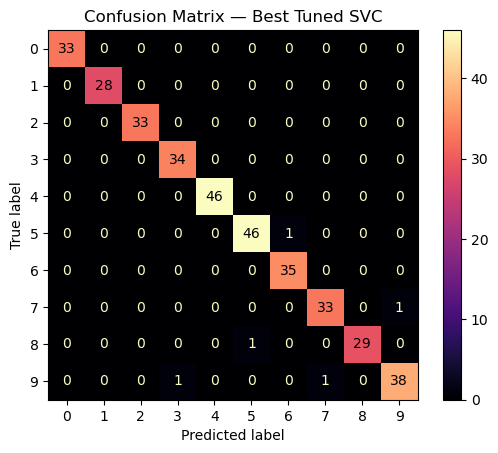

In [17]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=digits.target_names
)

disp.plot(cmap="magma", values_format="d")
plt.title("Confusion Matrix — Best Tuned SVC")
plt.show()

In [18]:
# Copy the confusion matrix and remove diagonal values
# Diagonal values are correct predictions, so we only want misclassifications
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Find all confused pairs where count > 0
confused_pairs = []

for true_label in range(cm_errors.shape[0]):
    for predicted_label in range(cm_errors.shape[1]):
        count = cm_errors[true_label, predicted_label]
        if count > 0:
            confused_pairs.append({
                "True Digit": true_label,
                "Predicted Digit": predicted_label,
                "Count": count
            })

confused_pairs_df = pd.DataFrame(confused_pairs)

if len(confused_pairs_df) > 0:
    confused_pairs_df = confused_pairs_df.sort_values(by="Count", ascending=False).reset_index(drop=True)
    display(confused_pairs_df)
else:
    print("No misclassifications found.")

,True Digit,Predicted Digit,Count
0,5,6,1
1,7,9,1
2,8,5,1
3,9,3,1
4,9,7,1


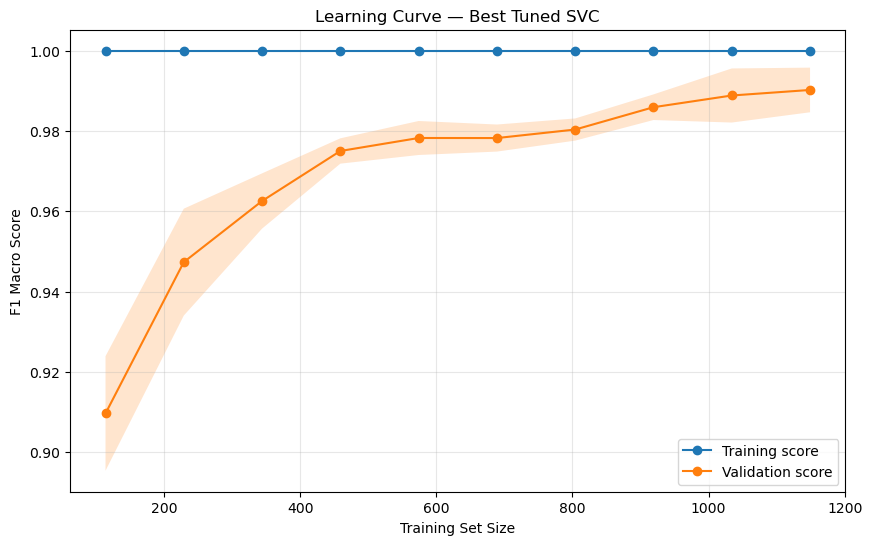

In [19]:
# Generate learning curve data
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_tuned_model,
    X=X_train,
    y=y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1_macro",
    n_jobs=-1
)

# Calculate mean and standard deviation for training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, validation_mean, marker="o", label="Validation score")

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("F1 Macro Score")
plt.title("Learning Curve — Best Tuned SVC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

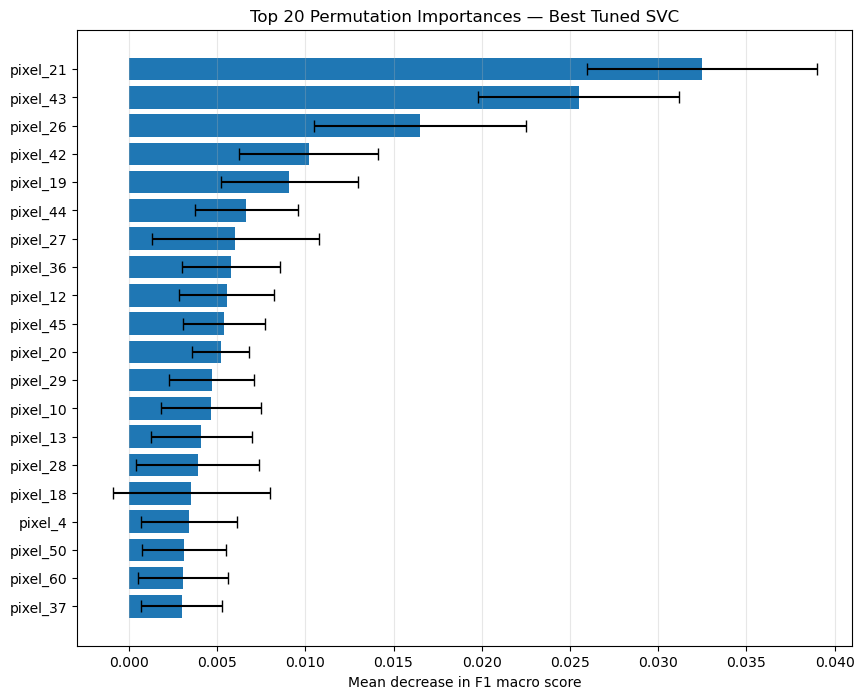

In [20]:
# Compute permutation importances on the test set
perm_importance = permutation_importance(
    estimator=best_tuned_model,
    X=X_test,
    y=y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Get the top 20 most important features
top_n = 20
top_indices = np.argsort(perm_importance.importances_mean)[-top_n:]

# Plot top 20 permutation importances
plt.figure(figsize=(10, 8))

plt.barh(
    range(top_n),
    perm_importance.importances_mean[top_indices],
    xerr=perm_importance.importances_std[top_indices],
    capsize=4
)

plt.yticks(range(top_n), [f"pixel_{i}" for i in top_indices])
plt.xlabel("Mean decrease in F1 macro score")
plt.title("Top 20 Permutation Importances — Best Tuned SVC")
plt.grid(axis="x", alpha=0.3)
plt.show()

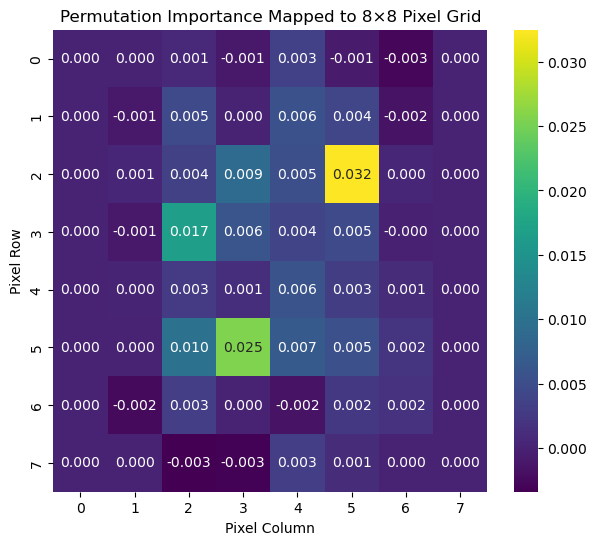

In [21]:
# Reshape feature importances into 8x8 image format
importance_grid = perm_importance.importances_mean.reshape(8, 8)

plt.figure(figsize=(7, 6))
sns.heatmap(
    importance_grid,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Permutation Importance Mapped to 8×8 Pixel Grid")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.show()

In [22]:
learning_curve_df = pd.DataFrame({
    "Training Size": train_sizes,
    "Training F1 Mean": train_mean,
    "Training F1 Std": train_std,
    "Validation F1 Mean": validation_mean,
    "Validation F1 Std": validation_std
})

learning_curve_df

,Training Size,Training F1 Mean,Training F1 Std,Validation F1 Mean,Validation F1 Std
0,114,1.0,0.0,0.909672,0.014259
1,229,1.0,0.0,0.947356,0.013307
2,344,1.0,0.0,0.962579,0.006879
3,459,1.0,0.0,0.975033,0.003153
4,574,1.0,0.0,0.978268,0.004233
5,689,1.0,0.0,0.978253,0.003370
6,804,1.0,0.0,0.980374,0.002760
7,919,1.0,0.0,0.985933,0.003191
8,1034,1.0,0.0,0.988850,0.006735
9,1149,1.0,0.0,0.990230,0.005558


## Task 4 Interpretation

In this task, the best tuned model from Task 3 was trained on the full training set and evaluated on the held-out test set. The selected model was `SVC(C=0.1, gamma='auto', kernel='poly')`.

The final test results were very strong. The model achieved an accuracy of 0.9861, macro precision of 0.9867, macro recall of 0.9866, and macro F1-score of 0.9866. These values show that the tuned SVC model generalizes well to unseen data. The classification report also shows that most digit classes were classified with very high precision and recall. Digits 0, 1, 2, and 4 were classified perfectly in the test set.

The confusion matrix shows that there were only five misclassified samples in total. The confused digit pairs were 5 predicted as 6, 7 predicted as 9, 8 predicted as 5, 9 predicted as 3, and 9 predicted as 7. These mistakes are understandable because handwritten digits can sometimes have similar shapes. For example, 9 and 7 may look similar if the loop or tail is unclear, and 5 and 6 can be confused if the lower part of the digit is rounded.

The learning curve shows that the training F1-score stayed at 1.0000 for all training sizes, while the validation F1-score improved as more training data was used. The validation score increased from about 0.9097 with the smallest training size to 0.9902 with the full training size. This means that the model benefits from having more data. There is still a small gap between the training and validation scores, but the validation performance is very high. Therefore, the model is not underfitting. It shows a small sign of overfitting because the training score is always perfect, but the gap becomes small at larger training sizes. Overall, the model can be considered well-fitted.

The permutation importance results show that some pixels are more important than others for classification. The most important features included pixel_21, pixel_43, pixel_26, pixel_42, and pixel_19. When mapped to the 8×8 pixel grid, the most important areas are mostly located around the central parts of the digit image. This makes intuitive sense because the middle pixels usually contain the main shape of handwritten digits, while corner pixels often contain little or no useful information.

To improve performance further, I would try a few possible steps. First, I could test a wider hyperparameter grid for SVC, especially more values for `C`, `gamma`, and polynomial degree. Second, I could apply feature scaling with `StandardScaler`, because SVC can be sensitive to feature ranges. Third, I could compare the result with more advanced models or image-specific approaches. However, because the current test performance is already very high, any further improvement would likely be small.